In [5]:
# ============================================================
# MIND — PRIMEIRO TREINAMENTO
# EC-DarkPattern + BERT multilíngue
# ============================================================

import os
import subprocess
import sys

# ------------------------------------------------------------
# 1. Clonar / atualizar o projeto
# ------------------------------------------------------------

%cd /content

if not os.path.exists("/content/MIND"):
    !git clone https://github.com/BeeyWasser/MIND.git
else:
    %cd /content/MIND
    !git pull

%cd /content/MIND

print("Projeto:", os.getcwd())

# ------------------------------------------------------------
# 2. Instalar dependências
# ------------------------------------------------------------

!pip install -q datasets transformers scikit-learn pandas torch

# ------------------------------------------------------------
# 3. Baixar a base EC-DarkPattern
# ------------------------------------------------------------

!python scripts/get_data.py --only ec-darkpattern

# ------------------------------------------------------------
# 4. Importações
# ------------------------------------------------------------

import pandas as pd
import numpy as np
import torch

from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# ------------------------------------------------------------
# 5. Verificar GPU
# ------------------------------------------------------------

print("\nGPU disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("ATENÇÃO: GPU não está disponível.")

# ------------------------------------------------------------
# 6. Carregar dataset
# ------------------------------------------------------------

arquivo = "data/ec-darkpattern/dataset.tsv"

df = pd.read_csv(
    arquivo,
    sep="\t"
)

df = df[["text", "label"]].dropna()

df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(int)

print("\nDataset:", df.shape)
print("\nDistribuição dos rótulos:")
print(df["label"].value_counts())

# ------------------------------------------------------------
# 7. Dividir treino / validação / teste
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("\nDivisão:")
print("Treino:", len(train_df))
print("Validação:", len(val_df))
print("Teste:", len(test_df))

# ------------------------------------------------------------
# 8. Converter para Hugging Face Dataset
# ------------------------------------------------------------

train_dataset = Dataset.from_pandas(
    train_df,
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df,
    preserve_index=False
)

# ------------------------------------------------------------
# 9. Modelo
# ------------------------------------------------------------

MODEL_NAME = "bert-base-multilingual-cased"

print("\nCarregando modelo:", MODEL_NAME)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# ------------------------------------------------------------
# 10. Tokenização
# ------------------------------------------------------------

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

# Renomear label para o formato esperado pelo Trainer
train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

train_dataset.set_format("torch")
val_dataset.set_format("torch")
test_dataset.set_format("torch")

# ------------------------------------------------------------
# 11. Métricas
# ------------------------------------------------------------

def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# ------------------------------------------------------------
# 12. Configuração do treinamento
# ------------------------------------------------------------

training_args = TrainingArguments(
    output_dir="./models/mind-darkpattern",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=2e-5,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,

    weight_decay=0.01,

    logging_steps=50,

    load_best_model_at_end=True,

    report_to="none"
)

# ------------------------------------------------------------
# 13. Trainer
# ------------------------------------------------------------

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

# ------------------------------------------------------------
# 14. TREINAMENTO
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("INICIANDO TREINAMENTO DO MIND")
print("=" * 60 + "\n")

trainer.train()

# ------------------------------------------------------------
# 15. Avaliação final
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("AVALIAÇÃO")
print("=" * 60)

resultado = trainer.evaluate(test_dataset)

print("\nResultado:")
for chave, valor in resultado.items():
    print(f"{chave}: {valor}")

# ------------------------------------------------------------
# 16. Salvar modelo
# ------------------------------------------------------------

modelo_final = "./models/mind-darkpattern-final"

trainer.save_model(modelo_final)
tokenizer.save_pretrained(modelo_final)

print("\nModelo salvo em:")
print(modelo_final)

print("\nTREINAMENTO CONCLUÍDO!")

/content
Cloning into 'MIND'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 29 (delta 2), reused 22 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 15.49 KiB | 7.75 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/MIND
Projeto: /content/MIND

Baixando 1 base(s) para data/

  baixando ec-darkpattern — 1 MB
  ok       ec-darkpattern — 1 arquivos em data/ec-darkpattern/

Pronto. O que é cada base está em DADOS.md.

GPU disponível: True
GPU: Tesla T4

Dataset: (2356, 2)

Distribuição dos rótulos:
label
1    1178
0    1178
Name: count, dtype: int64

Divisão:
Treino: 1884
Validação: 236
Teste: 236

Carregando modelo: bert-base-multilingual-cased


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

Map:   0%|          | 0/1884 [00:00<?, ? examples/s]

Map:   0%|          | 0/236 [00:00<?, ? examples/s]

Map:   0%|          | 0/236 [00:00<?, ? examples/s]


INICIANDO TREINAMENTO DO MIND



ImportError: cannot import name 'VideoReader' from 'torchvision.io' (/usr/local/lib/python3.13/dist-packages/torchvision/io/__init__.py)

In [6]:
!pip install -q -U "datasets>=4.8.4" "transformers" "accelerate" "scikit-learn" "pandas"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 118.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 13.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.


In [7]:
!pip install -q "pandas==2.2.3" "datasets>=4.8.4" "transformers" "accelerate" "scikit-learn"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 39.6 MB/s eta 0:00:00


In [1]:
import pandas as pd
import torch
import datasets
import transformers

print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("Datasets:", datasets.__version__)
print("Transformers:", transformers.__version__)
print("GPU:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Pandas: 2.2.3
PyTorch: 2.11.0+cu128
Datasets: 5.0.1
Transformers: 5.15.1
GPU: True
GPU: Tesla T4


In [2]:
# ============================================================
# MIND — PRIMEIRO TREINAMENTO
# EC-DarkPattern | Classificação binária
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# ------------------------------------------------------------
# 1. Ir para o projeto
# ------------------------------------------------------------

%cd /content

if not os.path.exists("/content/MIND"):
    !git clone https://github.com/BeeyWasser/MIND.git

%cd /content/MIND

# ------------------------------------------------------------
# 2. Baixar a base
# ------------------------------------------------------------

!python scripts/get_data.py --only ec-darkpattern

# ------------------------------------------------------------
# 3. Verificar GPU
# ------------------------------------------------------------

print("GPU disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# 4. Carregar dataset
# ------------------------------------------------------------

df = pd.read_csv(
    "data/ec-darkpattern/dataset.tsv",
    sep="\t"
)

df = df[["text", "label"]].dropna()

df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(int)

print("\nDataset:", df.shape)
print("\nDistribuição:")
print(df["label"].value_counts())

# ------------------------------------------------------------
# 5. Divisão 80 / 10 / 10
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("\nDivisão:")
print("Treino:", len(train_df))
print("Validação:", len(val_df))
print("Teste:", len(test_df))

# ------------------------------------------------------------
# 6. Hugging Face Dataset
# ------------------------------------------------------------

train_dataset = Dataset.from_pandas(
    train_df,
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df,
    preserve_index=False
)

# ------------------------------------------------------------
# 7. Modelo
# ------------------------------------------------------------

MODEL_NAME = "bert-base-multilingual-cased"

print("\nCarregando:", MODEL_NAME)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# ------------------------------------------------------------
# 8. Tokenização
# ------------------------------------------------------------

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

train_dataset = train_dataset.rename_column(
    "label", "labels"
)

val_dataset = val_dataset.rename_column(
    "label", "labels"
)

test_dataset = test_dataset.rename_column(
    "label", "labels"
)

# ------------------------------------------------------------
# 9. Métricas
# ------------------------------------------------------------

def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# ------------------------------------------------------------
# 10. Configuração
# ------------------------------------------------------------

training_args = TrainingArguments(
    output_dir="./models/mind-darkpattern",

    num_train_epochs=3,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=25,

    load_best_model_at_end=True,

    report_to="none"
)

# ------------------------------------------------------------
# 11. Trainer
# ------------------------------------------------------------

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_dataset,
    eval_dataset=val_dataset,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

# ------------------------------------------------------------
# 12. TREINAMENTO
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("INICIANDO TREINAMENTO DO MIND")
print("=" * 60)

resultado_treino = trainer.train()

print("\n" + "=" * 60)
print("TREINAMENTO CONCLUÍDO")
print("=" * 60)

# ------------------------------------------------------------
# 13. Avaliação no conjunto de teste
# ------------------------------------------------------------

print("\nAvaliando no conjunto de teste...")

resultado_teste = trainer.evaluate(
    eval_dataset=test_dataset,
    metric_key_prefix="test"
)

print("\nRESULTADOS:")
for chave, valor in resultado_teste.items():
    print(f"{chave}: {valor}")

# ------------------------------------------------------------
# 14. Salvar modelo
# ------------------------------------------------------------

modelo_final = "./models/mind-darkpattern-final"

trainer.save_model(modelo_final)
tokenizer.save_pretrained(modelo_final)

print("\nModelo salvo em:")
print(modelo_final)

print("\n🎉 PRIMEIRO TREINAMENTO DO MIND FINALIZADO!")

/content
/content/MIND

Baixando 1 base(s) para data/

  ok       ec-darkpattern (já baixado)

Pronto. O que é cada base está em DADOS.md.
GPU disponível: True
GPU: Tesla T4

Dataset: (2356, 2)

Distribuição:
label
1    1178
0    1178
Name: count, dtype: int64

Divisão:
Treino: 1884
Validação: 236
Teste: 236

Carregando: bert-base-multilingual-cased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/1884 [00:00<?, ? examples/s]

Map:   0%|          | 0/236 [00:00<?, ? examples/s]

...


TREINAMENTO CONCLUÍDO

Avaliando no conjunto de teste...


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.060899,0.097534,3,0.974576,0.974576,0.974576,0.974576



RESULTADOS:
test_loss: 0.09753412753343582
test_accuracy: 0.9745762711864406
test_precision: 0.9745762711864406
test_recall: 0.9745762711864406
test_f1: 0.9745762711864406


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Modelo salvo em:
./models/mind-darkpattern-final

🎉 PRIMEIRO TREINAMENTO DO MIND FINALIZADO!


In [3]:
# ============================================================
# MIND — EXPERIMENTO 2
# MentalManip | Classificação de manipulação
# ============================================================

import os
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# ------------------------------------------------------------
# 1. Ir para o projeto
# ------------------------------------------------------------

%cd /content/MIND

# ------------------------------------------------------------
# 2. Garantir que MentalManip está disponível
# ------------------------------------------------------------

!python scripts/get_data.py --only mentalmanip

# ------------------------------------------------------------
# 3. Carregar MentalManip
# ------------------------------------------------------------

arquivo = "data/mentalmanip/mentalmanip_detailed.csv"

df = pd.read_csv(arquivo)

print("Dataset original:", df.shape)

# ------------------------------------------------------------
# 4. Selecionar texto + rótulo
# ------------------------------------------------------------

df = df[["dialogue", "manipulative_1"]].dropna()

df = df.rename(
    columns={
        "dialogue": "text",
        "manipulative_1": "label"
    }
)

df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(int)

print("\nDataset:", df.shape)

print("\nDistribuição:")
print(df["label"].value_counts())

# ------------------------------------------------------------
# 5. Divisão estratificada
# ------------------------------------------------------------

train_df, temp_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    random_state=42,
    stratify=temp_df["label"]
)

print("\nDivisão:")
print("Treino:", len(train_df))
print("Validação:", len(val_df))
print("Teste:", len(test_df))

# ------------------------------------------------------------
# 6. Dataset Hugging Face
# ------------------------------------------------------------

train_dataset = Dataset.from_pandas(
    train_df,
    preserve_index=False
)

val_dataset = Dataset.from_pandas(
    val_df,
    preserve_index=False
)

test_dataset = Dataset.from_pandas(
    test_df,
    preserve_index=False
)

# ------------------------------------------------------------
# 7. Modelo multilíngue
# ------------------------------------------------------------

MODEL_NAME = "bert-base-multilingual-cased"

print("\nCarregando:", MODEL_NAME)

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# ------------------------------------------------------------
# 8. Tokenização
# ------------------------------------------------------------

def tokenize(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128
    )

train_dataset = train_dataset.map(
    tokenize,
    batched=True
)

val_dataset = val_dataset.map(
    tokenize,
    batched=True
)

test_dataset = test_dataset.map(
    tokenize,
    batched=True
)

# ------------------------------------------------------------
# 9. Labels
# ------------------------------------------------------------

train_dataset = train_dataset.rename_column(
    "label",
    "labels"
)

val_dataset = val_dataset.rename_column(
    "label",
    "labels"
)

test_dataset = test_dataset.rename_column(
    "label",
    "labels"
)

# ------------------------------------------------------------
# 10. Métricas
# ------------------------------------------------------------

def compute_metrics(eval_pred):

    predictions, labels = eval_pred

    predictions = np.argmax(
        predictions,
        axis=1
    )

    precision, recall, f1, _ = (
        precision_recall_fscore_support(
            labels,
            predictions,
            average="binary",
            zero_division=0
        )
    )

    accuracy = accuracy_score(
        labels,
        predictions
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# ------------------------------------------------------------
# 11. Configuração
# ------------------------------------------------------------

training_args = TrainingArguments(

    output_dir="./models/mind-mentalmanip",

    num_train_epochs=3,

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    learning_rate=2e-5,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=25,

    load_best_model_at_end=True,

    report_to="none"
)

# ------------------------------------------------------------
# 12. Trainer
# ------------------------------------------------------------

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_dataset,

    eval_dataset=val_dataset,

    processing_class=tokenizer,

    compute_metrics=compute_metrics
)

# ------------------------------------------------------------
# 13. TREINAMENTO
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("INICIANDO TREINAMENTO — MENTALMANIP")
print("=" * 60)

trainer.train()

# ------------------------------------------------------------
# 14. Teste
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("AVALIAÇÃO NO TESTE")
print("=" * 60)

resultado = trainer.evaluate(
    eval_dataset=test_dataset,
    metric_key_prefix="test"
)

print("\nRESULTADOS:")

for chave, valor in resultado.items():
    print(f"{chave}: {valor}")

# ------------------------------------------------------------
# 15. Salvar modelo
# ------------------------------------------------------------

modelo_final = "./models/mind-mentalmanip-final"

trainer.save_model(
    modelo_final
)

tokenizer.save_pretrained(
    modelo_final
)

print("\nModelo salvo em:")
print(modelo_final)

print("\n🎉 EXPERIMENTO MENTALMANIP CONCLUÍDO!")

/content/MIND

Baixando 1 base(s) para data/

  baixando mentalmanip — 18 MB
  ok       mentalmanip — 4 arquivos em data/mentalmanip/

Pronto. O que é cada base está em DADOS.md.
Dataset original: (4000, 27)

Dataset: (4000, 2)

Distribuição:
label
1    2640
0    1360
Name: count, dtype: int64

Divisão:
Treino: 3200
Validação: 400
Teste: 400

Carregando: bert-base-multilingual-cased


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

...


AVALIAÇÃO NO TESTE


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.501854,0.594471,3,0.692500,0.690027,0.969697,0.806299



RESULTADOS:
test_loss: 0.5944705009460449
test_accuracy: 0.6925
test_precision: 0.6900269541778976
test_recall: 0.9696969696969697
test_f1: 0.8062992125984252


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Modelo salvo em:
./models/mind-mentalmanip-final

🎉 EXPERIMENTO MENTALMANIP CONCLUÍDO!


Matriz de confusão:
[[ 21 115]
 [  8 256]]

Interpretação:
TN = 21
FP = 115
FN = 8
TP = 256


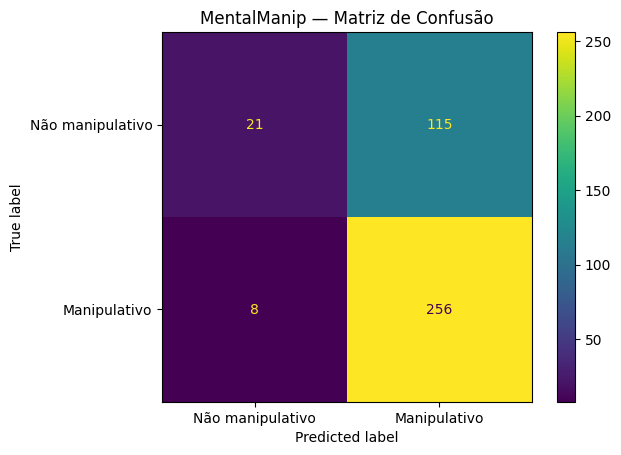

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Fazer previsões no conjunto de teste
pred = trainer.predict(test_dataset)

y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=1)

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)

print("Matriz de confusão:")
print(cm)

print("\nInterpretação:")
print("TN =", cm[0, 0])
print("FP =", cm[0, 1])
print("FN =", cm[1, 0])
print("TP =", cm[1, 1])

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Não manipulativo", "Manipulativo"]
).plot()

plt.title("MentalManip — Matriz de Confusão")
plt.show()

In [1]:
# ============================================================
# MIND — MODELO FINAL EC-DARKPATTERN
# Usa 100% dos dados disponíveis
# ============================================================

import os
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

%cd /content/MIND

# ------------------------------------------------------------
# 1. Carregar todos os dados
# ------------------------------------------------------------

arquivo = "data/ec-darkpattern/dataset.tsv"

df_ec_final = pd.read_csv(
    arquivo,
    sep="\t"
)

df_ec_final = df_ec_final[["text", "label"]].dropna()

df_ec_final["text"] = df_ec_final["text"].astype(str)
df_ec_final["label"] = df_ec_final["label"].astype(int)

print("Dataset:", df_ec_final.shape)

print("\nDistribuição:")
print(df_ec_final["label"].value_counts())

# ------------------------------------------------------------
# 2. Dataset Hugging Face
# ------------------------------------------------------------

dataset_ec_final = Dataset.from_pandas(
    df_ec_final,
    preserve_index=False
)

dataset_ec_final = dataset_ec_final.rename_column(
    "label",
    "labels"
)

# ------------------------------------------------------------
# 3. Modelo
# ------------------------------------------------------------

MODEL_NAME = "bert-base-multilingual-cased"

tokenizer_ec_final = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model_ec_final = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# ------------------------------------------------------------
# 4. Tokenização
# ------------------------------------------------------------

def tokenize_ec(batch):
    return tokenizer_ec_final(
        batch["text"],
        truncation=True,
        max_length=128
    )

dataset_ec_final = dataset_ec_final.map(
    tokenize_ec,
    batched=True
)

# ------------------------------------------------------------
# 5. Treinamento
# ------------------------------------------------------------

training_args_ec_final = TrainingArguments(
    output_dir="./models/mind-darkpattern-final-full",

    num_train_epochs=3,

    per_device_train_batch_size=16,

    learning_rate=2e-5,

    weight_decay=0.01,

    logging_steps=25,

    save_strategy="epoch",

    report_to="none"
)

trainer_ec_final = Trainer(
    model=model_ec_final,
    args=training_args_ec_final,
    train_dataset=dataset_ec_final,
    processing_class=tokenizer_ec_final
)

print("\n" + "=" * 60)
print("TREINANDO EC-DARKPATTERN — 100% DOS DADOS")
print("=" * 60)

trainer_ec_final.train()

# ------------------------------------------------------------
# 6. Salvar
# ------------------------------------------------------------

caminho_ec = "./models/mind-darkpattern-final-full"

trainer_ec_final.save_model(caminho_ec)
tokenizer_ec_final.save_pretrained(caminho_ec)

print("\nModelo salvo em:")
print(caminho_ec)

print("\n🎉 EC-DARKPATTERN FINALIZADO!")

[Errno 2] No such file or directory: '/content/MIND'
/content


FileNotFoundError: [Errno 2] No such file or directory: 'data/ec-darkpattern/dataset.tsv'

In [2]:
# ============================================================
# RECONSTRUIR O PROJETO MIND NO COLAB
# ============================================================

%cd /content

# Baixar o projeto do GitHub
!git clone https://github.com/BeeyWasser/MIND.git

# Entrar no projeto
%cd /content/MIND

# Conferir os arquivos
!ls

# Baixar a base necessária
!python scripts/get_data.py --only ec-darkpattern

print("\n============================================")
print("MIND RECONFIGURADO COM SUCESSO")
print("============================================")

print("\nLocal atual:")
!pwd

print("\nBase disponível:")
!ls data/ec-darkpattern/

/content
Cloning into 'MIND'...
remote: Enumerating objects: 29, done.
remote: Counting objects: 100% (29/29), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 29 (delta 2), reused 22 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (29/29), 15.49 KiB | 15.49 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/MIND
DADOS.md  data	LICENSE  README.md  scripts

Baixando 1 base(s) para data/

  baixando ec-darkpattern — 1 MB
  ok       ec-darkpattern — 1 arquivos em data/ec-darkpattern/

Pronto. O que é cada base está em DADOS.md.

MIND RECONFIGURADO COM SUCESSO

Local atual:
/content/MIND

Base disponível:
dataset.tsv


In [3]:
# ============================================================
# MIND — TREINAMENTO FINAL DOS DOIS DATASETS
# EC-DarkPattern + MentalManip
# Usa 100% dos dados disponíveis
# ============================================================

import os
import gc
import numpy as np
import pandas as pd
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

# ------------------------------------------------------------
# 1. Projeto
# ------------------------------------------------------------

%cd /content/MIND

print("=" * 60)
print("MIND — TREINAMENTO FINAL")
print("=" * 60)

print("\nGPU disponível:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# 2. Garantir que as duas bases estejam disponíveis
# ------------------------------------------------------------

print("\nBaixando/verificando bases...")

!python scripts/get_data.py --only ec-darkpattern mentalmanip

# ------------------------------------------------------------
# 3. MODELO 1 — EC-DARKPATTERN
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("1/2 — EC-DARKPATTERN")
print("=" * 60)

df_ec = pd.read_csv(
    "data/ec-darkpattern/dataset.tsv",
    sep="\t"
)

df_ec = df_ec[["text", "label"]].dropna()

df_ec["text"] = df_ec["text"].astype(str)
df_ec["label"] = df_ec["label"].astype(int)

print("\nExemplos:", len(df_ec))
print("Distribuição:")
print(df_ec["label"].value_counts())

dataset_ec = Dataset.from_pandas(
    df_ec,
    preserve_index=False
)

dataset_ec = dataset_ec.rename_column(
    "label",
    "labels"
)

MODEL_NAME = "bert-base-multilingual-cased"

tokenizer_ec = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model_ec = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

def tokenize_ec(batch):
    return tokenizer_ec(
        batch["text"],
        truncation=True,
        max_length=128
    )

dataset_ec = dataset_ec.map(
    tokenize_ec,
    batched=True
)

args_ec = TrainingArguments(
    output_dir="./models/mind-darkpattern-final-full",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=25,
    save_strategy="epoch",
    report_to="none"
)

trainer_ec = Trainer(
    model=model_ec,
    args=args_ec,
    train_dataset=dataset_ec,
    processing_class=tokenizer_ec
)

print("\nINICIANDO TREINAMENTO EC-DARKPATTERN...")

trainer_ec.train()

caminho_ec = "./models/mind-darkpattern-final-full"

trainer_ec.save_model(caminho_ec)
tokenizer_ec.save_pretrained(caminho_ec)

print("\n✓ EC-DARKPATTERN salvo em:")
print(caminho_ec)

# ------------------------------------------------------------
# Liberar memória da GPU
# ------------------------------------------------------------

del model_ec
del trainer_ec
del dataset_ec
del tokenizer_ec
del df_ec

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ------------------------------------------------------------
# 4. MODELO 2 — MENTALMANIP
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("2/2 — MENTALMANIP")
print("=" * 60)

df_mm = pd.read_csv(
    "data/mentalmanip/mentalmanip_detailed.csv"
)

df_mm = df_mm[
    ["dialogue", "manipulative_1"]
].dropna()

df_mm = df_mm.rename(
    columns={
        "dialogue": "text",
        "manipulative_1": "label"
    }
)

df_mm["text"] = df_mm["text"].astype(str)
df_mm["label"] = df_mm["label"].astype(int)

print("\nExemplos:", len(df_mm))
print("Distribuição:")
print(df_mm["label"].value_counts())

dataset_mm = Dataset.from_pandas(
    df_mm,
    preserve_index=False
)

dataset_mm = dataset_mm.rename_column(
    "label",
    "labels"
)

tokenizer_mm = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

model_mm = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

def tokenize_mm(batch):
    return tokenizer_mm(
        batch["text"],
        truncation=True,
        max_length=128
    )

dataset_mm = dataset_mm.map(
    tokenize_mm,
    batched=True
)

args_mm = TrainingArguments(
    output_dir="./models/mind-mentalmanip-final-full",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=25,
    save_strategy="epoch",
    report_to="none"
)

trainer_mm = Trainer(
    model=model_mm,
    args=args_mm,
    train_dataset=dataset_mm,
    processing_class=tokenizer_mm
)

print("\nINICIANDO TREINAMENTO MENTALMANIP...")

trainer_mm.train()

caminho_mm = "./models/mind-mentalmanip-final-full"

trainer_mm.save_model(caminho_mm)
tokenizer_mm.save_pretrained(caminho_mm)

print("\n✓ MENTALMANIP salvo em:")
print(caminho_mm)

# ------------------------------------------------------------
# 5. FINAL
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("🎉 TREINAMENTO FINAL CONCLUÍDO")
print("=" * 60)

print("\nModelos criados:")

print("\nEC-DarkPattern:")
!ls -lh models/mind-darkpattern-final-full

print("\nMentalManip:")
!ls -lh models/mind-mentalmanip-final-full

print("\nIMPORTANTE:")
print("Os modelos NÃO serão enviados ao GitHub.")
print("Os pesos estão protegidos pelo .gitignore.")
print("O código e o notebook serão enviados ao repositório.")

/content/MIND
MIND — TREINAMENTO FINAL

GPU disponível: True
GPU: Tesla T4

Baixando/verificando bases...

Baixando 2 base(s) para data/

  ok       ec-darkpattern (já baixado)
  baixando mentalmanip — 18 MB
  ok       mentalmanip — 4 arquivos em data/mentalmanip/

Pronto. O que é cada base está em DADOS.md.

1/2 — EC-DARKPATTERN

Exemplos: 2356
Distribuição:
label
1    1178
0    1178
Name: count, dtype: int64


config.json:   0%|          | 0.00/625 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✓ MENTALMANIP salvo em:
./models/mind-mentalmanip-final-full

🎉 TREINAMENTO FINAL CONCLUÍDO

Modelos criados:

EC-DarkPattern:
total 682M
drwxr-xr-x 2 root root 4.0K Aug 23 20:30 checkpoint-148
drwxr-xr-x 2 root root 4.0K Aug 23 20:31 checkpoint-296
drwxr-xr-x 2 root root 4.0K Aug 23 20:31 checkpoint-444
-rw-r--r-- 1 root root  932 Aug 23 20:31 config.json
-rw------- 1 root root 679M Aug 23 20:31 model.safetensors
-rw-r--r-- 1 root root  352 Aug 23 20:31 tokenizer_config.json
-rw-r--r-- 1 root root 2.8M Aug 23 20:31 tokenizer.json
-rw-r--r-- 1 root root 5.1K Aug 23 20:31 training_args.bin

MentalManip:
total 682M
drwxr-xr-x 2 root root 4.0K Aug 23 20:34 checkpoint-250
drwxr-xr-x 2 root root 4.0K Aug 23 20:36 checkpoint-500
drwxr-xr-x 2 root root 4.0K Aug 23 20:39 checkpoint-750
-rw-r--r-- 1 root root  932 Aug 23 20:39 config.json
-rw------- 1 root root 679M Aug 23 20:39 model.safetensors
-rw-r--r-- 1 root root  352 Aug 23 20:39 tokenizer_config.json
-rw-r--r-- 1 root root 2.8M Aug 23 